# NLTK resource downloads
This cell shows the NLTK resources you may need. Uncomment and run the commands if you haven't downloaded these packages yet.

In [17]:
# Download required NLTK resources (uncomment when running first time)
"""
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
"""

"\nnltk.download('punkt')\nnltk.download('stopwords')\nnltk.download('punkt_tab')\n"

# Prepare text and tokenize into sentences
This cell imports libraries, defines the example paragraph, lowercases and cleans each sentence, then tokenizes the paragraph into a `dataset` list of sentences.

In [18]:
# Import libraries used for preprocessing
import nltk
import re
import pandas as pd
from nltk.corpus import stopwords

# Multi-sentence example paragraph
text = """Beans. I was trying to explain to somebody as we were flying in, that's corn.
         That's beans. And they were very impressed at my agricultural knowledge. 
         Please give it up for Amaury once again for that outstanding introduction. 
         I have a bunch of good friends here today, including somebody who I served with, 
         who is one of the finest senators in the country, and we're lucky to have him, 
         your Senator, Dick Durbin is here. I also noticed, by the way, 
         former Governor Edgar here, who I haven't seen in a long time, and 
         somehow he has not aged and I have. And it's great to see you, Governor. 
         I want to thank President Killeen and everybody at the U of I System for 
         making it possible for me to be here today. And I am deeply honored at the Paul 
         Douglas Award that is being given to me. He is somebody who set the path for so 
         much outstanding public service here in Illinois. Now, I want to start by 
         addressing the elephant in the room. I know people are still wondering why 
         I didn't speak at the commencement."""

# Split paragraph into sentences
dataset = nltk.sent_tokenize(text)

# Basic cleaning: lowercase, remove non-word characters, collapse whitespace
for i in range(len(dataset)):
    dataset[i] = dataset[i].lower()
    dataset[i] = re.sub(r'\W', ' ', dataset[i])
    dataset[i] = re.sub(r'\s+', ' ', dataset[i])

# Show the cleaned sentences
for i, sentence in enumerate(dataset):
    print(f"Sentence {i+1}: {sentence}")

Sentence 1: beans 
Sentence 2: i was trying to explain to somebody as we were flying in that s corn 
Sentence 3: that s beans 
Sentence 4: and they were very impressed at my agricultural knowledge 
Sentence 5: please give it up for amaury once again for that outstanding introduction 
Sentence 6: i have a bunch of good friends here today including somebody who i served with who is one of the finest senators in the country and we re lucky to have him your senator dick durbin is here 
Sentence 7: i also noticed by the way former governor edgar here who i haven t seen in a long time and somehow he has not aged and i have 
Sentence 8: and it s great to see you governor 
Sentence 9: i want to thank president killeen and everybody at the u of i system for making it possible for me to be here today 
Sentence 10: and i am deeply honored at the paul douglas award that is being given to me 
Sentence 11: he is somebody who set the path for so much outstanding public service here in illinois 
Sente

# Count words per sentence and filter stop words
This cell builds a `word2count` dictionary with token frequencies across the whole paragraph, removes common English stopwords, and creates a `word_freq_df` DataFrame for easy inspection.

In [19]:
# Build frequency dictionary for all words
word2count = {}

for data in dataset:
    words = nltk.word_tokenize(data)
    for word in words:
        if word not in word2count:
            word2count[word] = 1
        else:
            word2count[word] += 1

# Remove English stop words from the frequency table
stop_words = set(stopwords.words('english'))

filtered_word2count = {word: count for word, count in word2count.items() if word not in stop_words}

# Convert to a DataFrame for readability and sort by frequency
word_freq_df = pd.DataFrame(list(filtered_word2count.items()), columns=['Word', 'Frequency'])
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)

print(word_freq_df)

            Word  Frequency
3       somebody          3
0          beans          2
12   outstanding          2
41          want          2
17         today          2
..           ...        ...
31        former          1
33         edgar          1
34          seen          1
35          long          1
71  commencement          1

[72 rows x 2 columns]


# Visualise the most frequent words
This cell selects the top words by raw frequency and plots a bar chart showing their counts.

Top 10 frequent words: ['i', 'the', 'to', 'and', 'in', 'for', 'here', 'that', 'at', 'who']


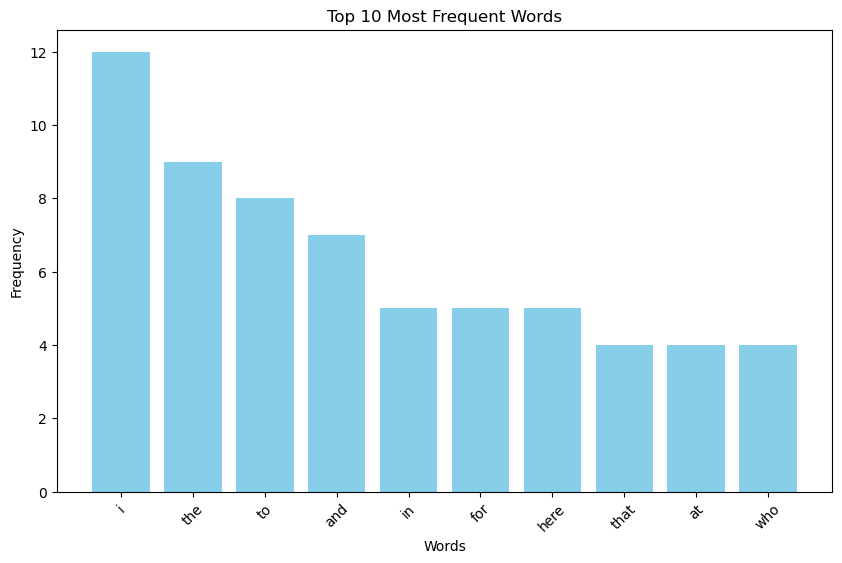

In [20]:
# Identify top words and plot their frequencies
import heapq
import matplotlib.pyplot as plt

# Get top 10 words by count from the full dictionary
freq_words = heapq.nlargest(10, word2count, key=word2count.get)

print(f"Top 10 frequent words: {freq_words}")

top_words = sorted(word2count.items(), key=lambda x: x[1], reverse=True)[:10]
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

# Build a binary Bag-of-Words matrix
This cell constructs a simple sentence-by-term binary matrix using the previously computed `freq_words`. Each row corresponds to a sentence and each column to one of the top frequent words; values are 1 if the word appears in the sentence, else 0. The matrix is plotted as a heatmap.

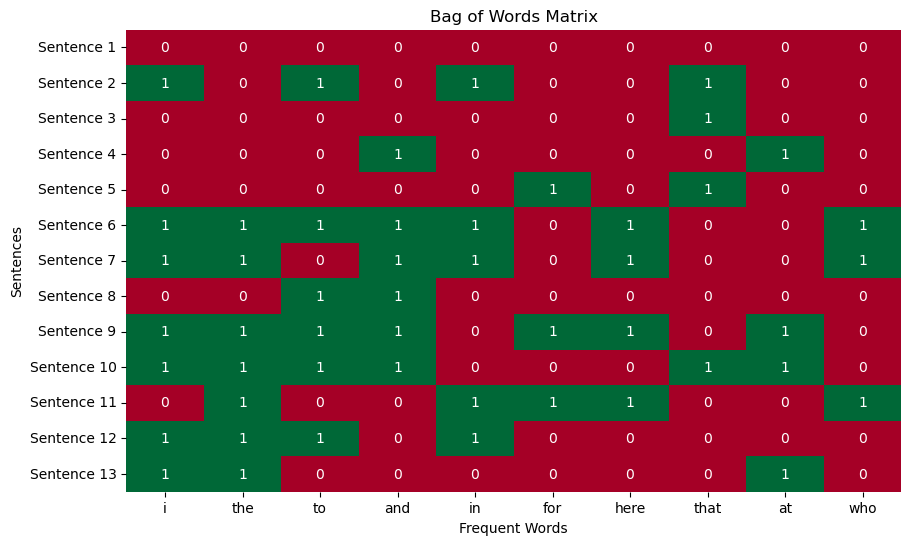

In [21]:
# Build binary sentence-term matrix for the top frequent words
import numpy as np
import seaborn as sns

X = []

for data in dataset:
    vector = []
    for word in freq_words:
        # Mark 1 if the word is present in the sentence, otherwise 0
        if word in nltk.word_tokenize(data):
            vector.append(1)
        else:
            vector.append(0)
    X.append(vector)

X = np.asarray(X)

plt.figure(figsize=(10, 6))
sns.heatmap(X, cmap='RdYlGn', cbar=False, annot=True, fmt="d", xticklabels=freq_words, yticklabels=[f"Sentence {i+1}" for i in range(len(dataset))])

plt.title('Bag of Words Matrix')
plt.xlabel('Frequent Words')
plt.ylabel('Sentences')
plt.show()

# CountVectorizer and TF-IDF examples (scikit-learn)
This cell shows how to convert the `dataset` of sentences into numeric matrices using `CountVectorizer` and `TfidfVectorizer`. These are standard, ML-ready representations: counts (sparse) and TF-IDF weights.

`CountVectorizer` creates a sparse matrix of token counts, while `TfidfVectorizer` computes the Term Frequency-Inverse Document Frequency weights, which reflect how important a word is to a sentence in the context of the whole paragraph. Both matrices are printed for inspection.

Count matrix (rows = sentences):


,addressing,aged,agricultural,amaury,award,beans,bunch,commencement,corn,country,...,service,set,somebody,speak,start,thank,time,today,trying,want
Sentence 1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Sentence 2,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
Sentence 3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Sentence 4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Sentence 5,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Sentence 6,0,0,0,0,0,0,1,0,0,1,...,0,0,1,0,0,0,0,1,0,0
Sentence 7,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
Sentence 8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Sentence 9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
Sentence 10,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


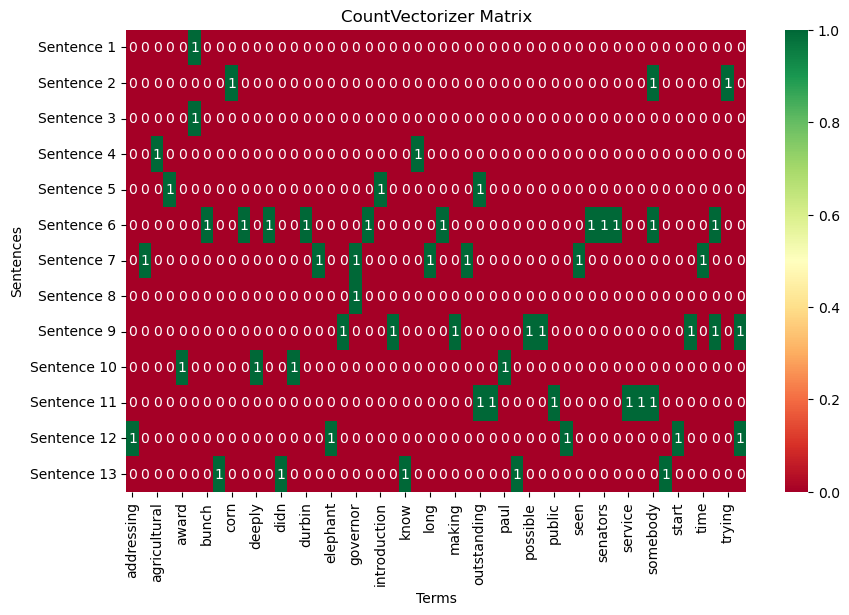

TF-IDF matrix (rows = sentences):


,addressing,aged,agricultural,amaury,award,beans,bunch,commencement,corn,country,...,service,set,somebody,speak,start,thank,time,today,trying,want
Sentence 1,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sentence 2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.621997,0.000000,...,0.000000,0.000000,0.475646,0.000000,0.000000,0.000000,0.000000,0.000000,0.621997,0.000000
Sentence 3,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sentence 4,0.000000,0.000000,0.707107,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sentence 5,0.000000,0.000000,0.000000,0.603718,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sentence 6,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.311159,0.000000,0.000000,0.311159,...,0.000000,0.000000,0.237946,0.000000,0.000000,0.000000,0.000000,0.268332,0.000000,0.000000
Sentence 7,0.000000,0.385081,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.385081,0.000000,0.000000,0.000000
Sentence 8,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sentence 9,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.365457,0.000000,0.315157,0.000000,0.315157
Sentence 10,0.000000,0.000000,0.000000,0.000000,0.5,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [24]:
# scikit-learn CountVectorizer + TfidfVectorizer example
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Choose max_features as you need (vocab size)
cv = CountVectorizer(stop_words='english', max_features=50)
X_counts = cv.fit_transform(dataset)                      # sparse matrix (n_sentences x n_features)
df_counts = pd.DataFrame(X_counts.toarray(),
                         columns=cv.get_feature_names_out(),
                         index=[f"Sentence {i+1}" for i in range(len(dataset))])
print("Count matrix (rows = sentences):")
display(df_counts)

# Optional heatmap for counts (binary/integers)
plt.figure(figsize=(10, 6))
sns.heatmap(df_counts, cmap='RdYlGn', annot=True, fmt="d")
plt.title('CountVectorizer Matrix')
plt.xlabel('Terms')
plt.ylabel('Sentences')
plt.show()

# TF-IDF version
tfidf = TfidfVectorizer(stop_words='english', max_features=50)
X_tfidf = tfidf.fit_transform(dataset)
df_tfidf = pd.DataFrame(X_tfidf.toarray(),
                        columns=tfidf.get_feature_names_out(),
                        index=[f"Sentence {i+1}" for i in range(len(dataset))])
print("TF-IDF matrix (rows = sentences):")
display(df_tfidf)

